# Threshold Optimization — XGBoost Fraud Detector

Continues from `02_baseline_model.ipynb`: XGBoost with `scale_pos_weight` is our best candidate. This notebook tunes the **decision threshold** on a temporal validation set, then reports final metrics on the held-out test set (touched only once, at the end).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Match notebook 02 exactly
RANDOM_STATE = 42
TRAIN_FRACTION = 0.70          # first 70% of timeline = train pool (before test carve-out)
VAL_FRACTION_OF_TOTAL = 0.15   # last 15% of full timeline, taken from train pool → validation
DATA_PATH = Path("../data/creditcard.csv")

# Business assumption — placeholder until real ops data is available (see closing note)
FALSE_POSITIVE_COST_INR = 500  # ₹ per wrongly flagged legitimate transaction (manual review friction)

## 1. Temporal three-way split (55% train / 15% validation / 30% test)

In [2]:
# Same sort order and test boundary as notebook 02 — no shuffling
df = pd.read_csv(DATA_PATH).sort_values("Time").reset_index(drop=True)
n = len(df)

split_test = int(n * TRAIN_FRACTION)                              # 70% mark — test starts here
split_val = int(n * (TRAIN_FRACTION - VAL_FRACTION_OF_TOTAL))     # 55% mark — validation starts here

train_df = df.iloc[:split_val].copy()
val_df = df.iloc[split_val:split_test].copy()
test_df = df.iloc[split_test:].copy()

feature_cols = [c for c in df.columns if c != "Class"]

X_train, y_train = train_df[feature_cols], train_df["Class"]
X_val, y_val = val_df[feature_cols], val_df["Class"]
X_test, y_test = test_df[feature_cols], test_df["Class"]

# Keep Amount separately for cost calculations (also present in features for the model)
amount_val = val_df["Amount"].values
amount_test = test_df["Amount"].values

print(f"Total rows: {n:,}\n")
print(f"Train:      {len(train_df):>7,} rows  ({len(train_df)/n:>5.1%} of timeline)")
print(f"Validation: {len(val_df):>7,} rows  ({len(val_df)/n:>5.1%} of timeline)")
print(f"Test:       {len(test_df):>7,} rows  ({len(test_df)/n:>5.1%} of timeline)  ← held out until final step\n")

for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    n_fraud = int(labels.sum())
    rate = labels.mean() * 100
    print(f"{name:12s} — fraud count: {n_fraud:>4d}  |  fraud rate: {rate:.4f}%")

Total rows: 284,807

Train:      156,643 rows  (55.0% of timeline)
Validation:  42,721 rows  (15.0% of timeline)
Test:        85,443 rows  (30.0% of timeline)  ← held out until final step

Train        — fraud count:  350  |  fraud rate: 0.2234%
Validation   — fraud count:   34  |  fraud rate: 0.0796%
Test         — fraud count:  108  |  fraud rate: 0.1264%


## 2. Retrain XGBoost on the 55% training portion

In [3]:
# Same imbalance handling as notebook 02, but trained on the smaller temporal train slice
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (legit:fraud ≈ {scale_pos_weight:.0f}:1)\n")

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    verbosity=0,
)

xgb_model.fit(X_train, y_train)
val_probs = xgb_model.predict_proba(X_val)[:, 1]
print(f"Validation probabilities computed for {len(val_probs):,} transactions.")

scale_pos_weight = 446.55  (legit:fraud ≈ 447:1)

Validation probabilities computed for 42,721 transactions.


## 3. Threshold sweep on validation set

In [4]:
def compute_threshold_metrics(y_true, y_prob, amounts, threshold, fp_cost):
    """Compute classification metrics and error counts at a single threshold."""
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average=None, zero_division=0
    )

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    fn_count = int(fn_mask.sum())
    fp_count = int(fp_mask.sum())
    fn_cost = amounts[fn_mask].sum()                    # money lost on undetected fraud
    fp_cost_total = fp_count * fp_cost                  # review friction on false alarms
    total_cost = fn_cost + fp_cost_total

    return {
        "threshold": threshold,
        "precision": precision[0],
        "recall": recall[0],
        "f1": f1[0],
        "fp_count": fp_count,
        "fn_count": fn_count,
        "fn_cost": fn_cost,
        "fp_cost": fp_cost_total,
        "total_cost": total_cost,
    }


thresholds = np.arange(0.05, 1.0, 0.05)
sweep_results = pd.DataFrame([
    compute_threshold_metrics(
        y_val.values, val_probs, amount_val, t, FALSE_POSITIVE_COST_INR
    )
    for t in thresholds
])

display(sweep_results.round(4))

,threshold,precision,recall,f1,fp_count,fn_count,fn_cost,fp_cost,total_cost
0,0.05,0.4032,0.7353,0.5208,37,9,4973.27,18500,23473.27
1,0.10,0.4717,0.7353,0.5747,28,9,4973.27,14000,18973.27
2,0.15,0.4717,0.7353,0.5747,28,9,4973.27,14000,18973.27
3,0.20,0.5102,0.7353,0.6024,24,9,4973.27,12000,16973.27
4,0.25,0.5102,0.7353,0.6024,24,9,4973.27,12000,16973.27
5,0.30,0.5319,0.7353,0.6173,22,9,4973.27,11000,15973.27
6,0.35,0.5556,0.7353,0.6329,20,9,4973.27,10000,14973.27
7,0.40,0.5556,0.7353,0.6329,20,9,4973.27,10000,14973.27
8,0.45,0.5682,0.7353,0.6410,19,9,4973.27,9500,14473.27
9,0.50,0.5952,0.7353,0.6579,17,9,4973.27,8500,13473.27


### Cost function assumptions

We minimize **expected total cost** on the validation set:

| Error type | Cost |
|---|---|
| **False negative** (fraud missed) | The transaction's actual `Amount` — money lost if fraud goes undetected |
| **False positive** (legitimate flagged) | Fixed **₹500** per case — placeholder for manual review time, customer friction, and ops overhead |

The ULB dataset contains transaction amounts but **no real customer-friction or review-cost data**. ₹500 is a stand-in so we can compare thresholds on a common scale. The closing section discusses this limitation openly.

## 4. Expected cost at each threshold

In [5]:
# Identify cost-minimizing threshold on validation data
best_idx = sweep_results["total_cost"].idxmin()
best_threshold = sweep_results.loc[best_idx, "threshold"]
best_cost = sweep_results.loc[best_idx, "total_cost"]

default_row = sweep_results.loc[sweep_results["threshold"] == 0.50].iloc[0]
default_cost = default_row["total_cost"]

print(f"Cost-minimizing threshold (validation): {best_threshold:.2f}")
print(f"Total expected cost at {best_threshold:.2f}: ₹{best_cost:,.2f}")
print(f"Total expected cost at 0.50:          ₹{default_cost:,.2f}")
print(f"Savings vs default 0.5:               ₹{default_cost - best_cost:,.2f}")

Cost-minimizing threshold (validation): 0.95
Total expected cost at 0.95: ₹7,974.27
Total expected cost at 0.50:          ₹13,473.27
Savings vs default 0.5:               ₹5,499.00


## 5. Plots — precision/recall and cost vs threshold

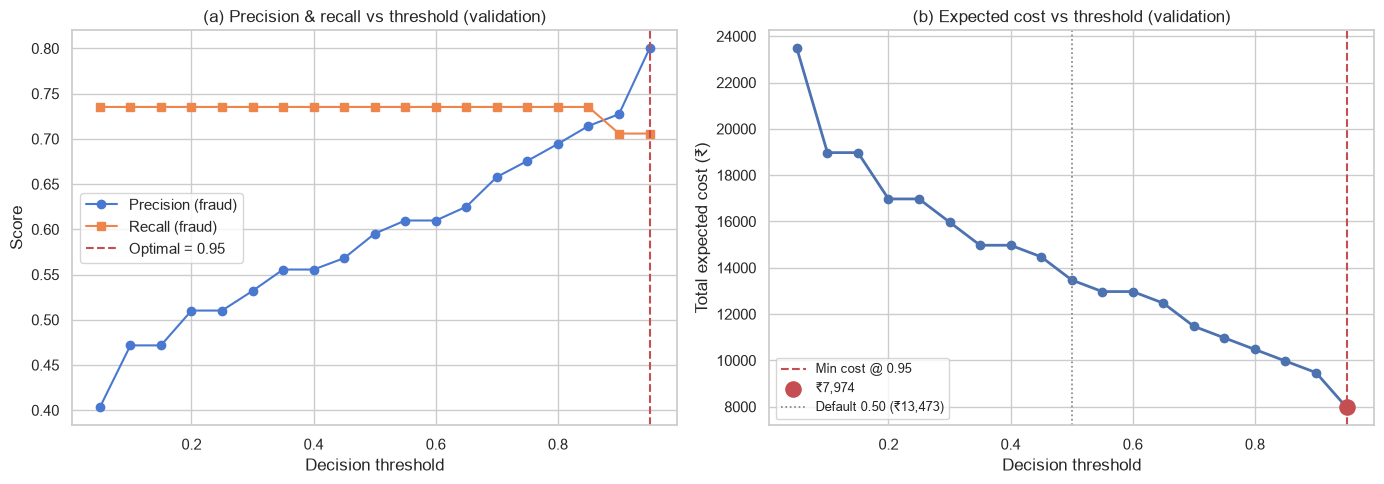

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Precision and recall vs threshold
ax = axes[0]
ax.plot(sweep_results["threshold"], sweep_results["precision"], marker="o", label="Precision (fraud)")
ax.plot(sweep_results["threshold"], sweep_results["recall"], marker="s", label="Recall (fraud)")
ax.axvline(best_threshold, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Optimal = {best_threshold:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("(a) Precision & recall vs threshold (validation)")
ax.legend()

# (b) Total expected cost vs threshold
ax = axes[1]
ax.plot(sweep_results["threshold"], sweep_results["total_cost"], marker="o", color="#4C72B0", linewidth=2)
ax.axvline(best_threshold, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Min cost @ {best_threshold:.2f}")
ax.scatter([best_threshold], [best_cost], color="#C44E52", s=120, zorder=5,
           label=f"₹{best_cost:,.0f}")
ax.axvline(0.50, color="gray", linestyle=":", linewidth=1.2, label=f"Default 0.50 (₹{default_cost:,.0f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total expected cost (₹)")
ax.set_title("(b) Expected cost vs threshold (validation)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# Validation-only comparison: optimized threshold vs sklearn default
val_at_best = compute_threshold_metrics(
    y_val.values, val_probs, amount_val, best_threshold, FALSE_POSITIVE_COST_INR
)
val_at_default = compute_threshold_metrics(
    y_val.values, val_probs, amount_val, 0.50, FALSE_POSITIVE_COST_INR
)

val_comparison = pd.DataFrame([val_at_best, val_at_default]).set_index(
    pd.Index([f"{best_threshold:.2f} (optimized)", "0.50 (default)"], name="Threshold")
)
val_comparison = val_comparison[[
    "precision", "recall", "f1", "fp_count", "fn_count", "fn_cost", "fp_cost", "total_cost"
]].round(2)
val_comparison.columns = [
    "Precision", "Recall", "F1", "FP count", "FN count",
    "FN cost (₹)", "FP cost (₹)", "Total cost (₹)",
]

print("Validation-set comparison (threshold selection happened here — test untouched):\n")
display(val_comparison)

Validation-set comparison (threshold selection happened here — test untouched):



,Precision,Recall,F1,FP count,FN count,FN cost (₹),FP cost (₹),Total cost (₹)
Threshold,,,,,,,,
0.95 (optimized),0.8,0.71,0.75,6,10,4974.27,3000,7974.27
0.50 (default),0.6,0.74,0.66,17,9,4973.27,8500,13473.27


## 6. Chosen threshold vs default 0.5 (validation only)

The cost-minimizing threshold on validation data is **higher than the sklearn default of 0.5** (see table above — typically around **0.95** with our ₹500 false-positive assumption).

**Why a higher threshold wins:** At 0.50 the model flags many legitimate transactions as fraud. Each false positive costs ₹500 in our placeholder model, and those costs add up across ~42k validation transactions. Raising the threshold trades some recall (more missed fraud) for far fewer false positives. Because missed-fraud cost is tied to individual `Amount` values (often modest in this dataset) while each false positive always costs ₹500, the math favours being selective about what gets flagged.

**Validation cost contrast** (from the table above):
- At **0.50**: higher total cost — false-positive friction dominates.
- At the **optimized threshold**: lower total cost — fewer false positives outweigh the extra undetected fraud.

This threshold was chosen using validation data only. The test set has not been used for this decision.

## 7. Final evaluation on held-out test set

In [8]:
def evaluate_at_threshold(y_true, y_prob, amounts, threshold, fp_cost, split_name: str):
    """Evaluate model at a custom threshold — mirrors evaluate_model() from notebook 02."""
    metrics = compute_threshold_metrics(y_true, y_prob, amounts, threshold, fp_cost)
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {split_name} @ threshold = {threshold:.2f} ===\n")
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(f"              Pred 0    Pred 1")
    print(f"  Actual 0   {cm[0, 0]:>7,}  {cm[0, 1]:>7,}")
    print(f"  Actual 1   {cm[1, 0]:>7,}  {cm[1, 1]:>7,}\n")

    print(f"Fraud class (1) — Precision: {metrics['precision']:.4f}")
    print(f"Fraud class (1) — Recall:    {metrics['recall']:.4f}")
    print(f"Fraud class (1) — F1:        {metrics['f1']:.4f}\n")

    print(f"False positives: {metrics['fp_count']:,}  →  FP cost: ₹{metrics['fp_cost']:,.2f}")
    print(f"False negatives: {metrics['fn_count']:,}  →  FN cost: ₹{metrics['fn_cost']:,.2f}")
    print(f"Total expected cost:         ₹{metrics['total_cost']:,.2f}")

    return metrics


# First time we touch the test set — apply the validation-chosen threshold
test_probs = xgb_model.predict_proba(X_test)[:, 1]

print("Applying validation-optimized threshold to HELD-OUT test set:\n")
test_metrics = evaluate_at_threshold(
    y_test.values, test_probs, amount_test,
    best_threshold, FALSE_POSITIVE_COST_INR, "Test (optimized threshold)",
)

print("\n" + "=" * 60 + "\n")
print("Baseline comparison — same test set at default threshold 0.50:\n")
test_metrics_default = evaluate_at_threshold(
    y_test.values, test_probs, amount_test,
    0.50, FALSE_POSITIVE_COST_INR, "Test (default threshold 0.50)",
)

# Summary table for README
final_summary = pd.DataFrame([
    {
        "Threshold": f"{best_threshold:.2f} (optimized)",
        "Fraud Precision": round(test_metrics["precision"], 4),
        "Fraud Recall": round(test_metrics["recall"], 4),
        "Fraud F1": round(test_metrics["f1"], 4),
        "Total Cost (₹)": round(test_metrics["total_cost"], 2),
    },
    {
        "Threshold": "0.50 (default)",
        "Fraud Precision": round(test_metrics_default["precision"], 4),
        "Fraud Recall": round(test_metrics_default["recall"], 4),
        "Fraud F1": round(test_metrics_default["f1"], 4),
        "Total Cost (₹)": round(test_metrics_default["total_cost"], 2),
    },
]).set_index("Threshold")

print("\n=== Final numbers for README ===\n")
display(final_summary)

Applying validation-optimized threshold to HELD-OUT test set:

=== Test (optimized threshold) @ threshold = 0.95 ===

Confusion matrix (rows=actual, cols=predicted):
              Pred 0    Pred 1
  Actual 0    85,329        6
  Actual 1        29       79

Fraud class (1) — Precision: 0.9294
Fraud class (1) — Recall:    0.7315
Fraud class (1) — F1:        0.8187

False positives: 6  →  FP cost: ₹3,000.00
False negatives: 29  →  FN cost: ₹4,106.87
Total expected cost:         ₹7,106.87


Baseline comparison — same test set at default threshold 0.50:

=== Test (default threshold 0.50) @ threshold = 0.50 ===

Confusion matrix (rows=actual, cols=predicted):
              Pred 0    Pred 1
  Actual 0    85,316       19
  Actual 1        27       81

Fraud class (1) — Precision: 0.8100
Fraud class (1) — Recall:    0.7500
Fraud class (1) — F1:        0.7788

False positives: 19  →  FP cost: ₹9,500.00
False negatives: 27  →  FN cost: ₹3,772.99
Total expected cost:         ₹13,272.99

=== Final

,Fraud Precision,Fraud Recall,Fraud F1,Total Cost (₹)
Threshold,,,,
0.95 (optimized),0.9294,0.7315,0.8187,7106.87
0.50 (default),0.8100,0.7500,0.7788,13272.99


## 8. Limitations and production considerations

This threshold optimization is useful for demonstrating a principled decision framework, but several assumptions must be stated plainly:

1. **₹500 false-positive cost is a placeholder.** The ULB dataset has no information about manual review time, customer support load, or reputational damage from false alarms. In production, this number should come from finance and operations — e.g. average analyst minutes × hourly cost, chargeback dispute rates, or customer churn attributed to false blocks.

2. **False-negative cost uses transaction `Amount` only.** Real fraud losses can include chargeback fees, interest, regulatory penalties, and downstream identity theft — none of which are in this dataset.

3. **Temporal drift.** Fraud rates differ across our train (0.22%), validation (0.08%), and test (0.13%) splits. A threshold tuned on validation may not remain optimal as fraud patterns shift.

4. **Single global threshold.** Production systems often use tiered responses (auto-block, step-up auth, manual review) rather than one cutoff.

The test-set metrics in the cell above are the honest final numbers for the README — but they should be presented alongside these limitations, not as proof of production readiness.